# Notebook 03 — Final model evaluation

This notebook performs the final evaluation of the ACT209 pricing frequency project.

The objective is to compare the Poisson GLM and Gradient Boosting models using:

1. test Poisson deviance;
2. calibration by predicted-risk decile;
3. lift by predicted-risk decile;
4. observed versus predicted frequency;
5. predicted-frequency stability;
6. extreme prediction diagnostics.

The models themselves were fitted in:

```text
02_modeling_glm_gb.ipynb
```

## Final evaluation setup

For each policy \(i\), the fitted models predict annual claim frequency:

\[
\widehat{\lambda}_i.
\]

The expected claim count is reconstructed using exposure:

\[
\widehat{\mu}_i = E_i \widehat{\lambda}_i.
\]

The final evaluation uses three complementary perspectives:

1. **Poisson deviance**: global predictive accuracy on the claim count scale;
2. **calibration**: whether predicted claim counts match observed claim counts by risk group;
3. **lift**: whether the model ranks policies from low risk to high risk.

A model can have good global deviance but poor calibration in some risk groups, or good ranking but unstable predicted levels. Therefore, these diagnostics must be analyzed together.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PERFORMANCE_PATH = OUTPUT_TABLES_DIR / "model_performance.csv"
TEST_PREDICTIONS_PATH = OUTPUT_TABLES_DIR / "test_predictions.csv"

print("Project root:", PROJECT_ROOT)
print("Model performance exists:", MODEL_PERFORMANCE_PATH.exists())
print("Test predictions exists:", TEST_PREDICTIONS_PATH.exists())

Project root: c:\Users\hoxhi\Desktop\act209_pricing_frequency
Model performance exists: True
Test predictions exists: True


In [3]:
from src.metrics import calibration_table_by_decile

## 1. Load modeling outputs

We load the outputs produced by `02_modeling_glm_gb.ipynb`:

- `model_performance.csv`: train, validation and test Poisson deviance;
- `test_predictions.csv`: test-set observed values and predictions.

The final evaluation is based only on the test set.

In [4]:
performance_table = pd.read_csv(MODEL_PERFORMANCE_PATH)
test_predictions = pd.read_csv(TEST_PREDICTIONS_PATH)

performance_table

,model,train_poisson_deviance,validation_poisson_deviance,test_poisson_deviance,validation_train_gap,test_train_gap
0,Constant benchmark,0.330765,0.331719,0.331425,0.000954,0.000660
1,Poisson GLM,0.320103,0.320796,0.321590,0.000693,0.001487
2,Gradient Boosting,0.298048,0.303698,0.305728,0.005650,0.007679


In [5]:
test_predictions.head()

,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimNb,Exposure,claim_frequency,lambda_constant,lambda_glm,lambda_gb,mu_constant,mu_glm,mu_gb
0,7,18,36,95,B1,Regular,D,1054,Centre,0,0.43,0.0,0.100298,0.147365,0.122336,0.043128,0.063367,0.052604
1,7,17,80,95,B2,Regular,D,598,Basse-Normandie,0,0.10,0.0,0.100298,0.172960,0.145429,0.010030,0.017296,0.014543
2,7,3,36,76,B6,Regular,E,4172,Rhone-Alpes,0,0.33,0.0,0.100298,0.180966,0.143599,0.033098,0.059719,0.047388
3,5,4,73,52,B13,Diesel,A,15,Centre,0,0.56,0.0,0.100298,0.097739,0.110630,0.056167,0.054734,0.061953
4,8,0,37,50,B11,Diesel,E,3021,Bretagne,0,0.27,0.0,0.100298,0.114937,0.091076,0.027080,0.031033,0.024590


In [6]:
required_columns = [
    "ClaimNb",
    "Exposure",
    "claim_frequency",
    "lambda_constant",
    "lambda_glm",
    "lambda_gb",
    "mu_constant",
    "mu_glm",
    "mu_gb",
]

missing_columns = [
    col for col in required_columns
    if col not in test_predictions.columns
]

if missing_columns:
    raise ValueError(f"Missing columns in test_predictions.csv: {missing_columns}")

print("All required columns are present.")

All required columns are present.


## 2. Global predictive performance

The first comparison is based on test Poisson deviance.

Poisson deviance is a loss: lower values indicate better predictive performance.

The comparison uses:

- constant frequency benchmark;
- Poisson GLM;
- Gradient Boosting with Poisson loss.

In [7]:
performance_table_sorted = performance_table.sort_values(
    by="test_poisson_deviance",
    ascending=True,
)

performance_table_sorted

,model,train_poisson_deviance,validation_poisson_deviance,test_poisson_deviance,validation_train_gap,test_train_gap
2,Gradient Boosting,0.298048,0.303698,0.305728,0.005650,0.007679
1,Poisson GLM,0.320103,0.320796,0.321590,0.000693,0.001487
0,Constant benchmark,0.330765,0.331719,0.331425,0.000954,0.000660


## 3. Calibration by predicted-risk decile

Calibration checks whether the predicted number of claims is consistent with the observed number of claims.

For a risk group \(g\), calibration is assessed by comparing:

\[
\sum_{i\in g} N_i
\]

with:

\[
\sum_{i\in g} \widehat{\mu}_i.
\]

The calibration ratio is:

\[
\frac{\sum_{i\in g} N_i}{\sum_{i\in g} \widehat{\mu}_i}.
\]

A ratio close to 1 indicates good calibration. A ratio above 1 indicates under-prediction, while a ratio below 1 indicates over-prediction.

The groups are predicted-risk deciles: the test policies are sorted by predicted frequency and split into ten groups of approximately equal size.

In [8]:
calibration_glm = calibration_table_by_decile(
    y_count=test_predictions["ClaimNb"],
    exposure=test_predictions["Exposure"],
    predicted_frequency=test_predictions["lambda_glm"],
    n_groups=10,
)

calibration_gb = calibration_table_by_decile(
    y_count=test_predictions["ClaimNb"],
    exposure=test_predictions["Exposure"],
    predicted_frequency=test_predictions["lambda_gb"],
    n_groups=10,
)

calibration_glm["model"] = "Poisson GLM"
calibration_gb["model"] = "Gradient Boosting"

calibration_glm

,risk_group,exposure,observed_claims,predicted_claims,min_predicted_frequency,max_predicted_frequency,mean_predicted_frequency,n_policies,observed_frequency,predicted_frequency,calibration_ratio_observed_over_predicted,lift_observed,model
0,1,8719.901598,432.0,451.854675,0.001676,0.059786,0.051855,13561,0.049542,0.051819,0.956060,0.490044,Poisson GLM
1,2,8513.573526,538.0,550.783508,0.059787,0.069342,0.064714,13560,0.063193,0.064695,0.976790,0.625076,Poisson GLM
2,3,8432.665877,655.0,621.271058,0.069345,0.077969,0.073707,13560,0.077674,0.073674,1.054290,0.768314,Poisson GLM
3,4,8050.697618,663.0,661.363746,0.077970,0.086290,0.082167,13560,0.082353,0.082150,1.002474,0.814597,Poisson GLM
4,5,7708.032121,664.0,698.549685,0.086290,0.095162,0.090695,13561,0.086144,0.090626,0.950541,0.852093,Poisson GLM
5,6,7063.268923,741.0,706.077760,0.095163,0.105116,0.100051,13560,0.104909,0.099965,1.049459,1.037708,Poisson GLM
6,7,6499.045894,710.0,719.217027,0.105117,0.116762,0.110760,13560,0.109247,0.110665,0.987185,1.080616,Poisson GLM
7,8,5943.818188,804.0,737.920769,0.116765,0.132898,0.124260,13560,0.135267,0.124149,1.089548,1.337991,Poisson GLM
8,9,5472.489695,872.0,802.194960,0.132898,0.166236,0.146861,13560,0.159342,0.146587,1.087018,1.576138,Poisson GLM
9,10,5220.929668,1162.0,1218.056710,0.166263,3.885052,0.232961,13561,0.222566,0.233303,0.953979,2.201511,Poisson GLM


In [9]:
calibration_gb

,risk_group,exposure,observed_claims,predicted_claims,min_predicted_frequency,max_predicted_frequency,mean_predicted_frequency,n_policies,observed_frequency,predicted_frequency,calibration_ratio_observed_over_predicted,lift_observed,model
0,1,8534.368975,386.0,367.778343,0.020896,0.052039,0.043336,13561,0.045229,0.043094,1.049545,0.447382,Gradient Boosting
1,2,7692.475847,427.0,440.042289,0.052040,0.062027,0.057255,13560,0.055509,0.057204,0.970361,0.549066,Gradient Boosting
2,3,7611.220343,463.0,503.758057,0.062027,0.070182,0.066188,13560,0.060831,0.066186,0.919092,0.601713,Gradient Boosting
3,4,7875.685715,543.0,580.313799,0.070186,0.076807,0.073632,13560,0.068946,0.073684,0.935701,0.681984,Gradient Boosting
4,5,8075.067703,641.0,642.961106,0.076807,0.082395,0.079633,13561,0.079380,0.079623,0.996950,0.785189,Gradient Boosting
5,6,8035.495130,686.0,686.886692,0.082395,0.088973,0.085486,13560,0.085371,0.085482,0.998709,0.844450,Gradient Boosting
6,7,7151.379361,706.0,675.559209,0.088975,0.103064,0.094736,13560,0.098722,0.094466,1.045060,0.976512,Gradient Boosting
7,8,5817.667816,665.0,664.317605,0.103064,0.126076,0.114337,13560,0.114307,0.114190,1.001027,1.130669,Gradient Boosting
8,9,5917.430704,979.0,877.775468,0.126079,0.183630,0.148340,13560,0.165443,0.148337,1.115319,1.636485,Gradient Boosting
9,10,4913.631512,1745.0,1711.872873,0.183636,9.760177,0.377514,13561,0.355134,0.348393,1.019351,3.512816,Gradient Boosting


In [10]:
calibration_glm.to_csv(
    OUTPUT_TABLES_DIR / "calibration_table_glm.csv",
    index=False,
)

calibration_gb.to_csv(
    OUTPUT_TABLES_DIR / "calibration_table_gb.csv",
    index=False,
)

## 4. Calibration plot

The calibration plot compares observed and predicted frequencies by predicted-risk decile.

For a well-calibrated model, observed and predicted frequencies should be close within each decile.

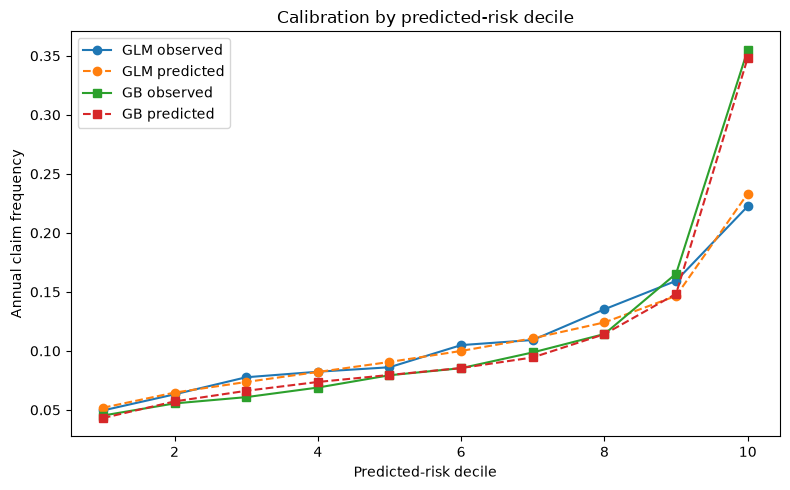

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    calibration_glm["risk_group"],
    calibration_glm["observed_frequency"],
    marker="o",
    label="GLM observed",
)

plt.plot(
    calibration_glm["risk_group"],
    calibration_glm["predicted_frequency"],
    marker="o",
    linestyle="--",
    label="GLM predicted",
)

plt.plot(
    calibration_gb["risk_group"],
    calibration_gb["observed_frequency"],
    marker="s",
    label="GB observed",
)

plt.plot(
    calibration_gb["risk_group"],
    calibration_gb["predicted_frequency"],
    marker="s",
    linestyle="--",
    label="GB predicted",
)

plt.xlabel("Predicted-risk decile")
plt.ylabel("Annual claim frequency")
plt.title("Calibration by predicted-risk decile")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "calibration_deciles.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Lift analysis

Lift measures the ranking ability of the model.

For a predicted-risk group \(g\), the observed lift is:

\[
\text{Lift}_g =
\frac{
\frac{\sum_{i\in g} N_i}{\sum_{i\in g} E_i}
}{
\frac{\sum_i N_i}{\sum_i E_i}
}.
\]

The model prediction is used to form the deciles. The lift itself is computed using observed claim frequency.

A high lift in the last decile means that the model successfully identifies a group of policies with claim frequency higher than the portfolio average.

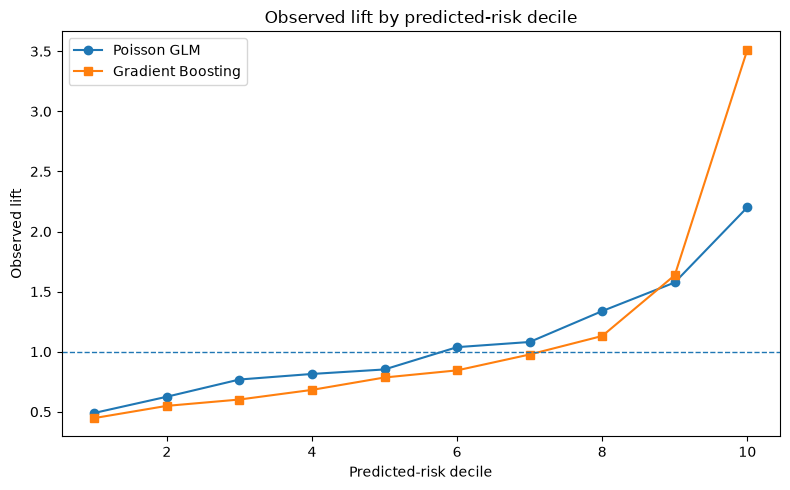

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    calibration_glm["risk_group"],
    calibration_glm["lift_observed"],
    marker="o",
    label="Poisson GLM",
)

plt.plot(
    calibration_gb["risk_group"],
    calibration_gb["lift_observed"],
    marker="s",
    label="Gradient Boosting",
)

plt.axhline(1.0, linestyle="--", linewidth=1)

plt.xlabel("Predicted-risk decile")
plt.ylabel("Observed lift")
plt.title("Observed lift by predicted-risk decile")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "lift_chart.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 6. Observed versus predicted frequency

The next diagnostic compares observed and predicted frequencies for each model separately.

This visualization helps detect local over-prediction or under-prediction by predicted-risk decile.

In [13]:
def plot_observed_vs_predicted_frequency(
    calibration_table: pd.DataFrame,
    model_name: str,
    output_path: Path,
) -> None:
    """
    Plot observed and predicted annual claim frequencies by risk group.

    Parameters
    ----------
    calibration_table : pd.DataFrame
        Calibration table produced by calibration_table_by_decile.
        It must contain 'risk_group', 'observed_frequency' and
        'predicted_frequency'.
    model_name : str
        Model name used in the plot title.
    output_path : pathlib.Path
        Path where the figure is saved.

    Returns
    -------
    None
        The function saves the figure and displays it.
    """
    plt.figure(figsize=(8, 5))

    plt.plot(
        calibration_table["risk_group"],
        calibration_table["observed_frequency"],
        marker="o",
        label="Observed frequency",
    )

    plt.plot(
        calibration_table["risk_group"],
        calibration_table["predicted_frequency"],
        marker="o",
        linestyle="--",
        label="Predicted frequency",
    )

    plt.xlabel("Predicted-risk decile")
    plt.ylabel("Annual claim frequency")
    plt.title(f"Observed versus predicted frequency — {model_name}")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

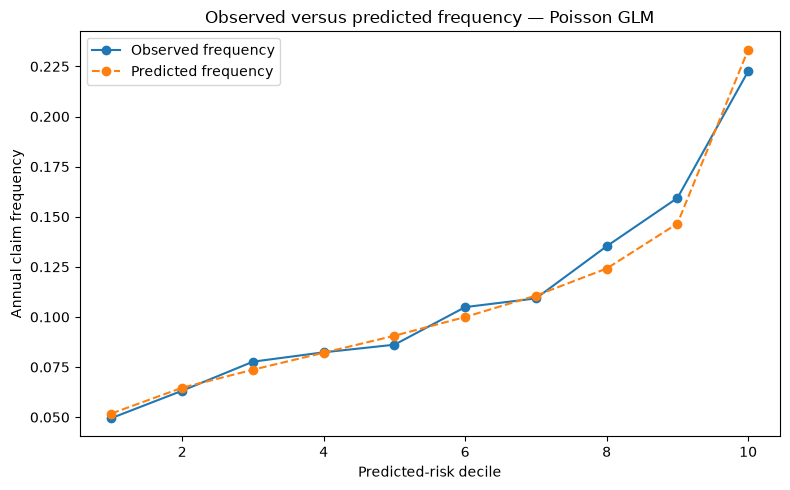

In [14]:
plot_observed_vs_predicted_frequency(
    calibration_table=calibration_glm,
    model_name="Poisson GLM",
    output_path=OUTPUT_FIGURES_DIR / "glm_observed_vs_predicted_frequency.png",
)

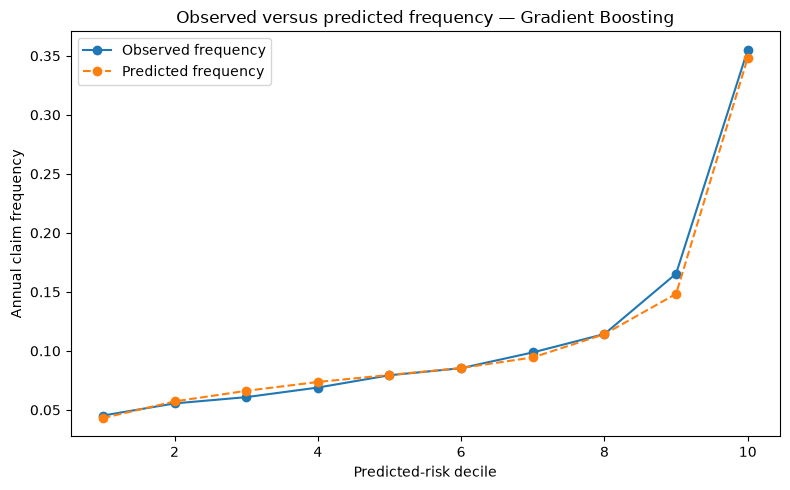

In [15]:
plot_observed_vs_predicted_frequency(
    calibration_table=calibration_gb,
    model_name="Gradient Boosting",
    output_path=OUTPUT_FIGURES_DIR / "gb_observed_vs_predicted_frequency.png",
)

## 7. Calibration and lift summary

We summarize calibration and lift with a few model-level indicators:

- mean absolute calibration error by decile;
- maximum absolute calibration error by decile;
- observed frequency in the top predicted-risk decile;
- predicted frequency in the top predicted-risk decile;
- observed lift in the top predicted-risk decile.

These indicators help compare the GLM and Gradient Boosting beyond global Poisson deviance.

In [16]:
def build_calibration_summary(
    calibration_table: pd.DataFrame,
    model_name: str,
) -> dict:
    """
    Build summary indicators from a calibration table.

    Parameters
    ----------
    calibration_table : pd.DataFrame
        Calibration table produced by calibration_table_by_decile.
    model_name : str
        Name of the model.

    Returns
    -------
    dict
        Dictionary containing calibration and lift summary indicators.

    Notes
    -----
    The calibration error is computed as:

        observed_frequency - predicted_frequency

    by predicted-risk decile.
    """
    table = calibration_table.copy()

    table["calibration_error"] = (
        table["observed_frequency"] - table["predicted_frequency"]
    )

    table["absolute_calibration_error"] = table["calibration_error"].abs()

    top_decile = table.loc[
        table["risk_group"] == table["risk_group"].max()
    ].iloc[0]

    return {
        "model": model_name,
        "mean_abs_calibration_error": table[
            "absolute_calibration_error"
        ].mean(),
        "max_abs_calibration_error": table[
            "absolute_calibration_error"
        ].max(),
        "top_decile_observed_frequency": top_decile[
            "observed_frequency"
        ],
        "top_decile_predicted_frequency": top_decile[
            "predicted_frequency"
        ],
        "top_decile_lift": top_decile["lift_observed"],
    }

In [17]:
calibration_summary = pd.DataFrame([
    build_calibration_summary(
        calibration_glm,
        "Poisson GLM",
    ),
    build_calibration_summary(
        calibration_gb,
        "Gradient Boosting",
    ),
])

calibration_summary

,model,mean_abs_calibration_error,max_abs_calibration_error,top_decile_observed_frequency,top_decile_predicted_frequency,top_decile_lift
0,Poisson GLM,0.005344,0.012756,0.222566,0.233303,2.201511
1,Gradient Boosting,0.004250,0.017106,0.355134,0.348393,3.512816


In [18]:
calibration_summary.to_csv(
    OUTPUT_TABLES_DIR / "calibration_summary.csv",
    index=False,
)

## 8. Top predicted-risk decile

The top decile is especially important for actuarial pricing because it contains the policies classified as the highest risk by the model.

We examine the last predicted-risk decile of the Gradient Boosting model, since Gradient Boosting produced the strongest lift in the previous analysis.

In [19]:
top_gb_decile = calibration_gb[
    calibration_gb["risk_group"] == calibration_gb["risk_group"].max()
]

top_gb_decile

,risk_group,exposure,observed_claims,predicted_claims,min_predicted_frequency,max_predicted_frequency,mean_predicted_frequency,n_policies,observed_frequency,predicted_frequency,calibration_ratio_observed_over_predicted,lift_observed,model
9,10,4913.631512,1745.0,1711.872873,0.183636,9.760177,0.377514,13561,0.355134,0.348393,1.019351,3.512816,Gradient Boosting


In [20]:
test_predictions_sorted_gb = test_predictions.sort_values(
    by="lambda_gb",
    ascending=False,
)

test_predictions_sorted_gb[
    [
        "ClaimNb",
        "Exposure",
        "claim_frequency",
        "lambda_glm",
        "lambda_gb",
        "mu_glm",
        "mu_gb",
    ]
].head(20)

,ClaimNb,Exposure,claim_frequency,lambda_glm,lambda_gb,mu_glm,mu_gb
92137,0,0.07,0.000000,0.066042,9.760177,0.004623,0.683212
88369,6,0.33,18.181818,0.066042,9.760177,0.021794,3.220858
107960,0,0.49,0.000000,0.058681,4.586731,0.028754,2.247498
105796,0,0.05,0.000000,0.293752,1.887848,0.014688,0.094392
93745,1,0.18,5.555556,0.253129,1.863622,0.045563,0.335452
13913,1,0.07,14.285714,0.321382,1.859170,0.022497,0.130142
89060,1,0.35,2.857143,0.364753,1.788587,0.127664,0.626006
133363,0,0.43,0.000000,0.379122,1.736057,0.163022,0.746505
12901,0,0.02,0.000000,0.379122,1.736057,0.007582,0.034721
112456,0,0.77,0.000000,0.250803,1.728996,0.193118,1.331327


## 9. Extreme predicted frequencies

The Gradient Boosting model improves risk segmentation, but it may also produce more extreme predicted frequencies.

This section compares the upper tails of the predicted-frequency distributions for the Poisson GLM and Gradient Boosting.

Extreme predictions are not necessarily wrong, but they should be monitored before operational actuarial use.

In [21]:
prediction_distribution = test_predictions[
    [
        "lambda_glm",
        "lambda_gb",
        "mu_glm",
        "mu_gb",
    ]
].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        0.995,
        0.999,
    ]
)

prediction_distribution

,lambda_glm,lambda_gb,mu_glm,mu_gb
count,135603.000000,135603.000000,135603.000000,135603.000000
mean,0.107803,0.114047,0.052855,0.052737
std,0.056744,0.122715,0.044037,0.059386
min,0.001676,0.020896,0.000027,0.000090
50%,0.095162,0.082395,0.047944,0.042091
75%,0.124009,0.114272,0.077023,0.072797
90%,0.166258,0.183635,0.102571,0.095693
95%,0.207738,0.305851,0.122483,0.132389
99%,0.323613,0.636624,0.193841,0.287542
99.5%,0.372546,0.891741,0.234160,0.368546


In [22]:
prediction_distribution.to_csv(
    OUTPUT_TABLES_DIR / "prediction_distribution_summary.csv",
)

## 10. Predicted frequency stability

Prediction stability is assessed by comparing the dispersion and upper tail of predicted annual frequencies.

A more stable model should have:

- lower standard deviation of predicted frequencies;
- less extreme upper quantiles;
- lower maximum predicted frequency.

This does not mean that the more stable model is necessarily more predictive. It means that its predicted levels are less dispersed and less extreme.

In [23]:
prediction_stability = pd.DataFrame({
    "model": ["Poisson GLM", "Gradient Boosting"],
    "mean_predicted_frequency": [
        test_predictions["lambda_glm"].mean(),
        test_predictions["lambda_gb"].mean(),
    ],
    "std_predicted_frequency": [
        test_predictions["lambda_glm"].std(),
        test_predictions["lambda_gb"].std(),
    ],
    "q99_predicted_frequency": [
        test_predictions["lambda_glm"].quantile(0.99),
        test_predictions["lambda_gb"].quantile(0.99),
    ],
    "q999_predicted_frequency": [
        test_predictions["lambda_glm"].quantile(0.999),
        test_predictions["lambda_gb"].quantile(0.999),
    ],
    "max_predicted_frequency": [
        test_predictions["lambda_glm"].max(),
        test_predictions["lambda_gb"].max(),
    ],
})

prediction_stability

,model,mean_predicted_frequency,std_predicted_frequency,q99_predicted_frequency,q999_predicted_frequency,max_predicted_frequency
0,Poisson GLM,0.107803,0.056744,0.323613,0.529880,3.885052
1,Gradient Boosting,0.114047,0.122715,0.636624,1.198751,9.760177


In [27]:
prediction_stability.to_csv(
    OUTPUT_TABLES_DIR / "prediction_stability.csv",
    index=False,
)

In [24]:
stability_plot_data = prediction_stability.set_index("model")[
    [
        "std_predicted_frequency",
        "q99_predicted_frequency",
        "q999_predicted_frequency",
        "max_predicted_frequency",
    ]
].T

stability_plot_data

model,Poisson GLM,Gradient Boosting
std_predicted_frequency,0.056744,0.122715
q99_predicted_frequency,0.323613,0.636624
q999_predicted_frequency,0.529880,1.198751
max_predicted_frequency,3.885052,9.760177


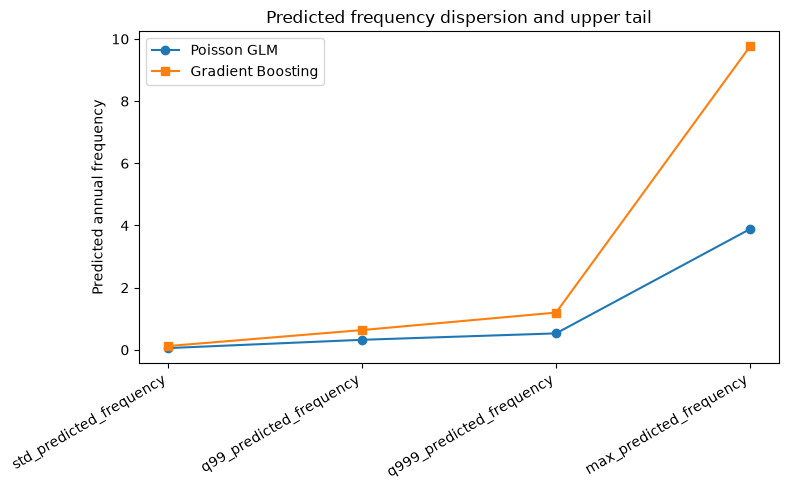

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    stability_plot_data.index,
    stability_plot_data["Poisson GLM"],
    marker="o",
    label="Poisson GLM",
)

plt.plot(
    stability_plot_data.index,
    stability_plot_data["Gradient Boosting"],
    marker="s",
    label="Gradient Boosting",
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Predicted annual frequency")
plt.title("Predicted frequency dispersion and upper tail")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "prediction_stability.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 11. Interpretation summary

The final diagnostics should be read together:

- Poisson deviance evaluates global predictive performance.
- Calibration checks whether predicted claim counts are close to observed claim counts by risk group.
- Lift evaluates the model ranking of low-risk to high-risk policies.
- Prediction stability checks whether the model produces very dispersed or extreme predicted frequencies.

A good actuarial model should not be selected only from a single metric.

In [28]:
expected_outputs = [
    OUTPUT_TABLES_DIR / "calibration_table_glm.csv",
    OUTPUT_TABLES_DIR / "calibration_table_gb.csv",
    OUTPUT_TABLES_DIR / "calibration_summary.csv",
    OUTPUT_TABLES_DIR / "prediction_distribution_summary.csv",
    OUTPUT_TABLES_DIR / "prediction_stability.csv",
    OUTPUT_FIGURES_DIR / "calibration_deciles.png",
    OUTPUT_FIGURES_DIR / "lift_chart.png",
    OUTPUT_FIGURES_DIR / "glm_observed_vs_predicted_frequency.png",
    OUTPUT_FIGURES_DIR / "gb_observed_vs_predicted_frequency.png",
    OUTPUT_FIGURES_DIR / "prediction_stability.png",
]

output_check = pd.DataFrame({
    "file": [
        str(path.relative_to(PROJECT_ROOT))
        for path in expected_outputs
    ],
    "exists": [
        path.exists()
        for path in expected_outputs
    ],
})

output_check

,file,exists
0,outputs\tables\calibration_table_glm.csv,True
1,outputs\tables\calibration_table_gb.csv,True
2,outputs\tables\calibration_summary.csv,True
3,outputs\tables\prediction_distribution_summary...,True
4,outputs\tables\prediction_stability.csv,True
5,outputs\figures\calibration_deciles.png,True
6,outputs\figures\lift_chart.png,True
7,outputs\figures\glm_observed_vs_predicted_freq...,True
8,outputs\figures\gb_observed_vs_predicted_frequ...,True
9,outputs\figures\prediction_stability.png,True


# Final conclusion

The final evaluation confirms that the Gradient Boosting model provides the best predictive performance among the tested models. It achieves the lowest test Poisson deviance, improving both the constant benchmark and the Poisson GLM.

The calibration analysis shows that both models are reasonably calibrated by predicted-risk decile, although local deviations remain. Gradient Boosting provides strong predictive segmentation, but it can also show larger local deviations in some deciles.

The lift analysis shows that both models rank risks in an increasing way. However, the Gradient Boosting model produces a stronger separation of high-risk policies, especially in the top predicted-risk decile. This indicates better risk ranking and segmentation.

The analysis of predicted frequencies also shows that Gradient Boosting produces a small number of very high predicted frequencies. These predictions are not necessarily wrong, because they may correspond to genuinely high-risk profiles. Nevertheless, they should be monitored before any operational actuarial use, especially because extreme predictions may be driven by small exposures, rare combinations of risk factors, or local overfitting.

Overall, Gradient Boosting is the best predictive model in this study, while the Poisson GLM remains an important actuarial benchmark because it is simpler, more stable and more interpretable.